In [1]:
import os
os.environ["HF_HOME"] = "/raid/s3/opengptx/behzad_shomali/custom_hf_cache/"

import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from collections import defaultdict
from trl import setup_chat_format

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
from pathlib import Path
import os

In [3]:
# ---- Settings ----
# base_model_name = "meta-llama/Llama-3.2-3B"
# finetuned_model_name = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-18_41_56/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-20_53_57/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_02-11_13_11/checkpoint-2000/lora_merged/"

# base_model_name = "Behzadshomali/Teuken3.7B"
finetuned_model_name = "/raid/s3/opengptx/behzad_shomali/hf_converted/recuEmbed-math-group-rec_3_last3__6_7_8__-2025-10-17__13-07-48"

sample_text = "Hannah sold 40 pieces of cookies for $0.8 each and 30 cupcakes for $2 each. She used the money to buy 2 sets of measuring spoons for $6.5 each. How much money does she have left?"

# ---- Load models ----
# base_model = AutoModel.from_pretrained(base_model_name, output_hidden_states=True, trust_remote_code=True)
ft_model = AutoModel.from_pretrained(finetuned_model_name, output_hidden_states=True, trust_remote_code=True).to("cuda:0")
tokenizer = AutoTokenizer.from_pretrained(finetuned_model_name)

# if tokenizer.chat_template is None:
#     base_model, tokenizer = setup_chat_format(base_model, tokenizer)

# # Put models in eval mode
# base_model.eval()
ft_model.eval()


GPT2Model(
  (embed_tokens): Embedding(251008, 1024, padding_idx=0)
  (layers): ModuleList(
    (0-5): 6 x GPT2DecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (o_proj): Linear(in_features=1024, out_features=1024, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear(in_features=1024, out_features=2816, bias=False)
        (up_proj): Linear(in_features=1024, out_features=2816, bias=False)
        (down_proj): Linear(in_features=2816, out_features=1024, bias=False)
        (act_fn): SiLU()
      )
      (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (6): GroupRecursiveGPT2DecoderLayer(
      (gpt2_blocks): ModuleList(
  

In [5]:
ft_model

GPT2Model(
  (embed_tokens): Embedding(251008, 1024, padding_idx=0)
  (layers): ModuleList(
    (0-5): 6 x GPT2DecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (o_proj): Linear(in_features=1024, out_features=1024, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear(in_features=1024, out_features=2816, bias=False)
        (up_proj): Linear(in_features=1024, out_features=2816, bias=False)
        (down_proj): Linear(in_features=2816, out_features=1024, bias=False)
        (act_fn): SiLU()
      )
      (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (6): GroupRecursiveGPT2DecoderLayer(
      (gpt2_blocks): ModuleList(
  

In [9]:
# ---- Weight Differences ----
weight_diffs = []
layer_names = []

with torch.no_grad():
    for (n1, p1), (n2, p2) in zip(base_model.named_parameters(), ft_model.named_parameters()):
        if p1.shape == p2.shape:
            diff = (p1 - p2).abs().mean().item()
            weight_diffs.append(diff)
            layer_names.append(n1)
        else:
            print(f"Skipping {n1} due to shape mismatch: {p1.shape} vs {p2.shape}")

# ---- Activation Differences ----
inputs = tokenizer(sample_text, return_tensors="pt")

with torch.no_grad():
    base_out = base_model(**inputs)
    ft_out = ft_model(**inputs)

# Extract hidden states (list of [batch, seq_len, hidden_size])
base_hs = base_out.hidden_states
ft_hs = ft_out.hidden_states

act_diffs = []
layer_ids = list(range(len(base_hs)))

for h1, h2 in zip(base_hs, ft_hs):
    diff = (h1.mean(dim=(0,1)) - h2.mean(dim=(0,1))).abs().mean().item()
    act_diffs.append(diff)



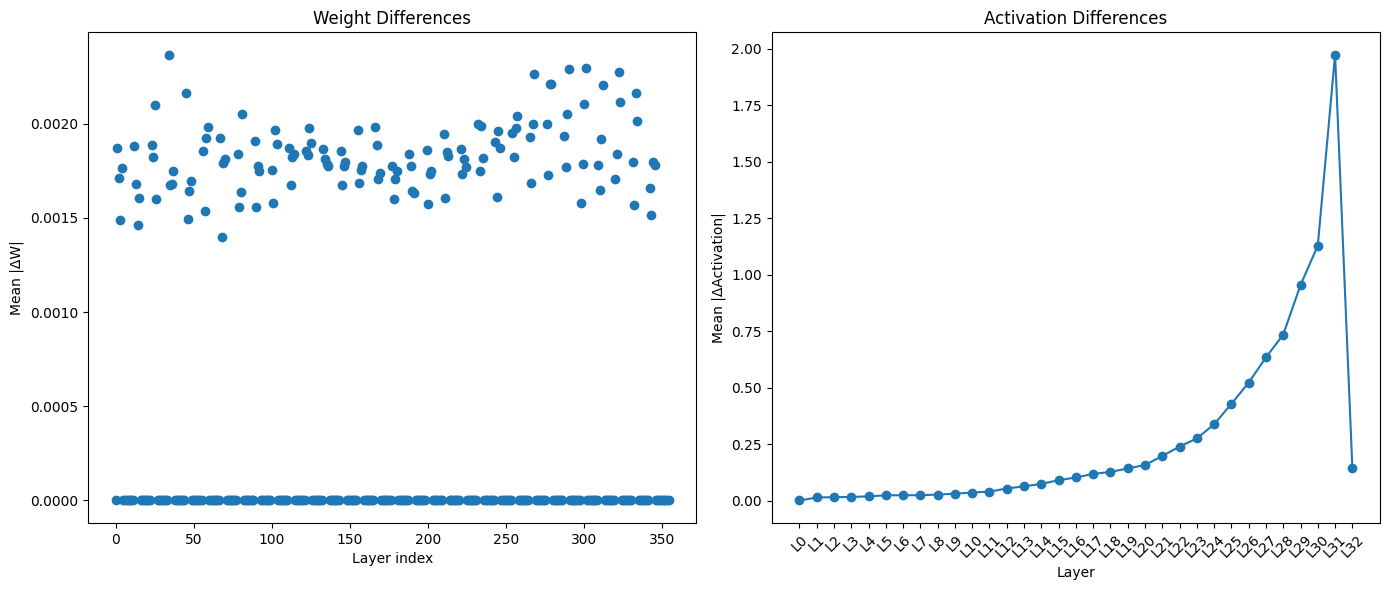

In [10]:
# ---- Plot ----
plt.figure(figsize=(14,6))

# Plot weight differences
plt.subplot(1,2,1)
plt.scatter(range(len(weight_diffs)), weight_diffs, marker='o')
plt.title("Weight Differences")
plt.xlabel("Layer index")
plt.ylabel("Mean |ΔW|")
plt.tight_layout()

# Plot activation differences
plt.subplot(1,2,2)
plt.plot(layer_ids, act_diffs, marker='o')
plt.xticks(range(len(layer_ids)), [f"L{i}" for i in layer_ids], rotation=45)
plt.title("Activation Differences")
plt.xlabel("Layer")
plt.ylabel("Mean |ΔActivation|")

plt.tight_layout()
plt.show()

In [11]:
for i in range(len(weight_diffs)):
    print(f"Layer {layer_names[i]} --> Weight Diff = {weight_diffs[i]:.6f}")

Layer embed_tokens.weight --> Weight Diff = 0.000004
Layer layers.0.self_attn.q_proj.weight --> Weight Diff = 0.001869
Layer layers.0.self_attn.k_proj.weight --> Weight Diff = 0.001713
Layer layers.0.self_attn.v_proj.weight --> Weight Diff = 0.001491
Layer layers.0.self_attn.o_proj.weight --> Weight Diff = 0.001768
Layer layers.0.mlp.gate_proj.weight --> Weight Diff = 0.000000
Layer layers.0.mlp.up_proj.weight --> Weight Diff = 0.000000
Layer layers.0.mlp.down_proj.weight --> Weight Diff = 0.000000
Layer layers.0.input_layernorm.weight --> Weight Diff = 0.000000
Layer layers.0.input_layernorm.bias --> Weight Diff = 0.000000
Layer layers.0.post_attention_layernorm.weight --> Weight Diff = 0.000000
Layer layers.0.post_attention_layernorm.bias --> Weight Diff = 0.000000
Layer layers.1.self_attn.q_proj.weight --> Weight Diff = 0.001880
Layer layers.1.self_attn.k_proj.weight --> Weight Diff = 0.001682
Layer layers.1.self_attn.v_proj.weight --> Weight Diff = 0.001460
Layer layers.1.self_attn

In [1]:
from pathlib import Path

In [8]:
file_dir = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/"
file_dir = Path(file_dir)
json_files = [f for f in file_dir.glob("*.json") if f.is_file() and "results" in f.name]
json_files

[PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T16-24-08.464414.json'),
 PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T17-06-05.599449.json'),
 PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T17-23-45.980589.json'),
 PosixPath('/raid/s3/opengptx/behzad_shomali/instruction_tuning/Llama3.1_3B_IT_OpenMathInstruct-2/2025_09_01-11_04_00/checkpoint-2000/lora_merged/results_2025-09-01T15-53-26.500130.json')]

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
from transformers import AutoConfig, AutoModelForCausalLM


model_names = [
    "Behzadshomali/Teuken3.7B",
    "meta-llama/Llama-3.1-8B",
    "meta-llama/Llama-3.2-3B"
]

for model_name in model_names:
    print("=="*10, f"Model: {model_name}", "=="*10)
    config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)

    print("Number of hidden layers:", config.num_hidden_layers)

    # If you load the model, you can also count directly:
    model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
    print("Layers in transformer:", len(model.model.layers))
    print()

    del model

The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.


==================== Model: Behzadshomali/Teuken3.7B ====================


A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.


Number of hidden layers: 32


A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- modeling_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  2.90s/it]


Layers in transformer: 32

==================== Model: meta-llama/Llama-3.1-8B ====================
Number of hidden layers: 32


Loading checkpoint shards: 100%|██████████| 4/4 [00:15<00:00,  3.81s/it]


Layers in transformer: 32

==================== Model: meta-llama/Llama-3.2-3B ====================
Number of hidden layers: 28


Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.24s/it]


Layers in transformer: 28



In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities_orig/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/miniforge3/envs/modalities_orig/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
model = AutoModelForCausalLM.from_pretrained("Behzadshomali/Teuken3.7B", torch_dtype=torch.bfloat16, trust_remote_code=True)
# tokenizer = AutoTokenizer.from_pretrained("tomg-group-umd/huginn-0125")


The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- configuration_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!
The module name Behzadshomali/Teuken3_dot_7B (originally Behzadshomali/Teuken3.7B) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/Behzadshomali/Teuken3.7B:
- modeling_gpt2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
Loading checkpoint shards: 100%|██████████| 4

In [11]:
model

GPT2ForCausalLM(
  (model): GPT2Model(
    (embed_tokens): Embedding(250880, 4096, padding_idx=0)
    (layers): ModuleList(
      (0-31): 32 x GPT2DecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
      )
    )
 

In [ ]:
dummy_input = torch.tensor([[12, 34, 56, 78, 90]])
input_embeddings = model.get_input_embeddings()(dummy_input)


In [9]:
logits = model(input_ids=dummy_input).logits
logits

tensor([[[ -6.0625,  -6.1250,  -6.1562,  ...,  -1.9844,  -2.3906,  -0.3242],
         [-11.0000, -10.3125, -10.6875,  ...,  -8.3750,  -6.2188,  -5.6562],
         [ -9.6250,  -9.3750,  -9.4375,  ...,  -4.4062,  -2.4844,  -0.5859],
         [ -9.6875,  -9.3750,  -9.4375,  ...,  -4.4688,  -2.4844,  -0.6328],
         [ -9.6875,  -9.4375,  -9.5000,  ...,  -4.3750,  -2.3125,  -0.3711]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>)

In [14]:
model(inputs_embeds=input_embeddings).logits

tensor([[[ -6.0625,  -6.1250,  -6.1562,  ...,  -1.9844,  -2.3906,  -0.3242],
         [-11.0000, -10.3125, -10.6875,  ...,  -8.3750,  -6.2188,  -5.6562],
         [ -9.6250,  -9.3750,  -9.4375,  ...,  -4.4062,  -2.4844,  -0.5859],
         [ -9.6875,  -9.3750,  -9.4375,  ...,  -4.4688,  -2.4844,  -0.6328],
         [ -9.6875,  -9.4375,  -9.5000,  ...,  -4.3750,  -2.3125,  -0.3711]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>)

In [ ]:
model.get_input_embeddings().weight

torch.Size([250880, 4096])

In [10]:
torch.matmul(logits, model.get_input_embeddings().weight).shape

torch.Size([1, 5, 4096])

In [4]:
input_embeddings.shape

torch.Size([1, 5, 4096])

In [5]:
logits.shape

torch.Size([1, 5, 250880])

In [2]:
model = AutoModelForCausalLM.from_pretrained("tomg-group-umd/huginn-0125", torch_dtype=torch.bfloat16, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("tomg-group-umd/huginn-0125")


The module name tomg_hyphen_group_hyphen_umd/huginn_hyphen_0125 (originally tomg-group-umd/huginn-0125) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/tomg-group-umd/huginn-0125:
- raven_config_minimal.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!
The module name tomg_hyphen_group_hyphen_umd/huginn_hyphen_0125 (originally tomg-group-umd/huginn-0125) is not a valid Python identifier. Please rename the original module to avoid import issues.
A new version of the following files was downloaded from https://huggingface.co/tomg-group-umd/huginn-0125:
- raven_modeling_minimal.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin 

In [3]:
model

RavenForCausalLM(
  (transformer): ModuleDict(
    (wte): Embedding(65536, 5280)
    (prelude): ModuleList(
      (0-1): 2 x SandwichBlock(
        (norm_1): RMSNorm()
        (attn): CausalSelfAttention(
          (Wqkv): Linear(in_features=5280, out_features=15840, bias=False)
          (proj): Linear(in_features=5280, out_features=5280, bias=False)
        )
        (norm_2): RMSNorm()
        (mlp): GatedMLP(
          (fc): Linear(in_features=5280, out_features=35840, bias=False)
          (proj): Linear(in_features=17920, out_features=5280, bias=False)
          (nonlin): SiLU()
        )
        (norm_3): RMSNorm()
        (norm_4): RMSNorm()
      )
    )
    (adapter): Linear(in_features=10560, out_features=5280, bias=False)
    (core_block): ModuleList(
      (0-3): 4 x SandwichBlock(
        (norm_1): RMSNorm()
        (attn): CausalSelfAttention(
          (Wqkv): Linear(in_features=5280, out_features=15840, bias=False)
          (proj): Linear(in_features=5280, out_feature

In [15]:
import torch
import torch.nn as nn
from pydantic import BaseModel
from typing import Any, Dict, Optional, Tuple
from torch import Tensor
from dataclasses import dataclass


@dataclass
class PonderingModelConfig(BaseModel):
    """Configuration for registering with Modalities."""
    base_model_config: Dict[str, Any]
    pondering_steps: int = 3
    pondering_position: str = "after_embed"
    hidden_size: int = 768
    num_attention_heads: int = 12
    intermediate_size: int = 3072
    dropout: float = 0.1

In [16]:
PonderingModelConfig.model_fields

{'base_model_config': FieldInfo(annotation=Dict[str, Any], required=True),
 'pondering_steps': FieldInfo(annotation=int, required=False, default=3),
 'pondering_position': FieldInfo(annotation=str, required=False, default='after_embed'),
 'hidden_size': FieldInfo(annotation=int, required=False, default=768),
 'num_attention_heads': FieldInfo(annotation=int, required=False, default=12),
 'intermediate_size': FieldInfo(annotation=int, required=False, default=3072),
 'dropout': FieldInfo(annotation=float, required=False, default=0.1)}

In [1]:
# !pip install pydantic==1.10

In [11]:
from pydantic import BaseModel, Field
from typing import Annotated

class ModelExample(BaseModel):
    x: int = Field(...)

# Try instantiating
try:
    # This will fail in Pydantic v1 if type is wrong
    m = ModelExample(x='123', strict=True)  # string instead of int
    print("Instantiated:", m, type(m.x))
except Exception as e:
    print("Error:", e)

# Try passing strict=True in constructor
# try:
#     m2 = ModelExample(x="12ds3", strict=False)
#     print("Instantiated with strict=True:", m2, type(m2.x))
# except TypeError as e:
#     print("TypeError:", e)

Instantiated: x=123 <class 'int'>


In [1]:
import torch

print("---- no_grad() example ----")
x = torch.tensor(1.0, requires_grad=True)
with torch.no_grad():
    y = x * 2  # no graph created
z = y * torch.tensor(3.0, requires_grad=True)
print("z.requires_grad:", z.requires_grad)  # True (because the new 3.0 tensor requires grad)
z.backward()
print("x.grad:", x.grad)  # None, no_grad() cut x out
print("z.grad_fn:", z.grad_fn)  # has grad_fn from the second tensor

print("\n---- detach() example ----")
x = torch.tensor(1.0, requires_grad=True)
y = x * 2
y_detached = y.detach()  # cut graph here
w = torch.tensor(3.0, requires_grad=True)
z = y_detached * w
print("z.requires_grad:", z.requires_grad)  # True, because z depends on w
z.backward()
print("x.grad:", x.grad)  # None, detached killed link
print("w.grad:", w.grad)  # Nonzero, because z still has a valid graph from w


---- no_grad() example ----
z.requires_grad: True
x.grad: None
z.grad_fn: <MulBackward0 object at 0x7f417439cc10>

---- detach() example ----
z.requires_grad: True
x.grad: None
w.grad: tensor(2.)


In [1]:

# os.environ["HF_HOME"] = "/raid/s3/opengptx/behzad_shomali/custom_hf_cache/"

import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from collections import defaultdict
from trl import setup_chat_format

/raid/s3/opengptx/behzad_shomali/miniforge3/envs/lighteval_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/raid/s3/opengptx/behzad_shomali/miniforge3/envs/lighteval_env/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
from recursive_llama2.recursive_llama import RecursiveLlamaForCausalLM, RecursiveLlamaConfig

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

from transformers import AutoConfig, AutoModelForCausalLM
from transformers import AutoModel, AutoTokenizer


# Register the classes
AutoConfig.register("recursive-llama", RecursiveLlamaConfig)
AutoModelForCausalLM.register(RecursiveLlamaConfig, RecursiveLlamaForCausalLM)

print("✓ Recursive Llama classes registered!")

✓ Recursive Llama classes registered!
✓ Recursive Llama classes registered!


In [3]:

# finetuned_model_name = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/dummy/2025_11_02-20_18_16/checkpoint-50"
finetuned_model_name = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/dummy/2025_11_02-20_23_15/checkpoint-100"


# ---- Load models ----
# base_model = AutoModel.from_pretrained(base_model_name, output_hidden_states=True, trust_remote_code=True)
# config = AutoConfig.from_pretrained(finetuned_model_name)
ft_model = AutoModelForCausalLM.from_pretrained(finetuned_model_name, output_hidden_states=True, trust_remote_code=True).to("cuda:0")
tokenizer = AutoTokenizer.from_pretrained(finetuned_model_name)

ft_model = ft_model.eval()


The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


9
10
11
12
13
14
15
Number of final layers: 16


In [4]:
ft_model.config.num_recursions

1

In [6]:
batch_input = tokenizer(
    [
        # """Context: A woman is sitting on a couch with a laptop on her lap. She opens the laptop and begins typing. She looks up at the TV and
        # Choices:
        # A) turns off the TV before returning to her work.
        # B) throws the laptop across the room.
        # C) jumps up and starts dancing around wildly.
        # D) puts on her shoes and walks outside.

        # Question: Which ending best completes the context?
        # Answer:""",
        # # "Hello world this is Behzad !!!!"
        "The key to life is fsd "
    ]
    , return_tensors="pt").to("cuda")

In [7]:
ft_model.model.layers[8].num_recursions = 4
ft_model.model.layers[8].layer_idx = 8

torch.allclose(
    ft_model.generate(**batch_input, use_cache=True,  do_sample=False),
    ft_model.generate(**batch_input, use_cache=False, do_sample=False)
)

after rotation cache -0.0005294614238664508 -- 0.17333121597766876 -- -0.002770023187622428
after update cache -0.0005294614238664508 -- 0.17333121597766876 -- -0.0027700229547917843

after rotation cache 0.03378761559724808 -- -0.07785525172948837 -- 0.00014902775001246482
after update cache 0.03378761559724808 -- -0.07785525918006897 -- 0.0001490268186898902

after rotation cache 0.0061112577095627785 -- -0.015741318464279175 -- -0.00018671114230528474
after update cache 0.0061112577095627785 -- -0.015741322189569473 -- -0.0001867109240265563

after rotation cache 0.07410404831171036 -- -0.04181380197405815 -- 0.001022005220875144
after update cache 0.07410404831171036 -- -0.04181380942463875 -- 0.0010220046387985349

after rotation cache 0.018369819968938828 -- 0.07379792630672455 -- -0.0012874393723905087
after update cache 0.018369819968938828 -- 0.07379792630672455 -- -0.0012874393723905087

after rotation cache 0.012348487041890621 -- -0.06395943462848663 -- 0.001386796007864177

False

In [7]:
ft_model

RecursiveLlamaForCausalLM(
  (model): RecursiveLlamaModel(
    (embed_tokens): Embedding(128258, 2048, padding_idx=128257)
    (rotary_emb): LlamaRotaryEmbedding()
    (layers): ModuleList(
      (0-7): 8 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), 

In [11]:
p = """\
Context: A woman is sitting on a couch with a laptop on her lap. She opens the laptop and begins typing. She looks up at the TV and
Choices:
A) throws the laptop across the room.
B) turns off the TV before returning to her work.
C) jumps up and starts dancing around wildly.
D) puts on her shoes and walks outside.

Question: Which ending best completes the context?
Answer:"""

In [10]:
ft_model = ft_model.eval()
ft_model.model.layers[8].num_recursions = 2
prompt = "Yesterday I saw"

In [65]:
from transformers import pipeline
pipe = pipeline(
    "text-generation", 
    tokenizer=tokenizer,
    model=ft_model, 
    torch_dtype=torch.bfloat16, 
    device_map="auto",
    use_cache=True,
    # past_key_values=None,
    # temperature=0.1,
    do_sample=False,
)
pipe(prompt)[0]["generated_text"]

Device set to use cuda:0


'Yesterday I saw a video of a man who was able to walk on the ceiling of a building. He was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to walk on the ceiling of a building and he was able to

In [66]:
from transformers import pipeline
pipe = pipeline(
    "text-generation", 
    tokenizer=tokenizer,
    model=ft_model, 
    torch_dtype=torch.bfloat16, 
    device_map="auto",
    use_cache=False,
    # past_key_values=None,
    # temperature=0.1,
    do_sample=False,
)
pipe(prompt)[0]["generated_text"]

Device set to use cuda:0


'Yesterday I saw a video of a man who was able to walk on water. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to walk on water for about 30 seconds. He was able to wa

In [11]:
input_ = tokenizer(prompt, return_tensors="pt").to("cuda")

In [12]:
logits_w_cache = ft_model(**input_, use_cache=True, do_sample=False)["logits"]
logits_w_cache

tensor([[[ 6.6970,  8.4766, 12.1905,  ..., -3.7017,  0.0454, -0.4398],
         [12.7124,  9.3706,  7.7201,  ...,  0.1065,  5.0591,  5.1310],
         [ 8.1295, 10.1479,  6.5659,  ..., -0.0774,  4.3606,  4.4381],
         [ 8.8506,  7.4104,  4.6652,  ...,  0.2271,  4.7925,  4.9809]]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>)

In [13]:
logits_wo_cache = ft_model(**input_, use_cache=False, do_sample=False)["logits"]
logits_wo_cache

tensor([[[ 6.6971,  8.4764, 12.1903,  ..., -3.7017,  0.0454, -0.4399],
         [12.6430,  9.3868,  7.7271,  ...,  0.0970,  5.0527,  5.1236],
         [ 8.1012, 10.1323,  6.6087,  ..., -0.0867,  4.3565,  4.4324],
         [ 8.7572,  7.3839,  4.7038,  ...,  0.2261,  4.7813,  4.9699]]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>)

In [14]:
diff = logits_wo_cache - logits_w_cache

In [15]:
torch.isclose(diff, torch.zeros_like(diff))

tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]]], device='cuda:0')

In [72]:
torch.sum(torch.isclose(diff, torch.zeros_like(diff), atol=1e-5)) / torch.numel(diff)

tensor(0.0104, device='cuda:0')

In [17]:
torch.mean(torch.abs(diff), dim=2)

tensor([[0.0002, 0.0268, 0.0372, 0.0607]], device='cuda:0',
       grad_fn=<MeanBackward1>)